In [25]:
import matplotlib.pyplot as plt
import dask.array as da
from skimage.measure import label
import tifffile
import skimage as ski
import pandas as pd
import os
import numpy as np
from scipy import ndimage as ndi
import ops_process as ops
import distinctipy
from matplotlib.colors import ListedColormap


In [2]:
# read in image
root = "/Users/hannahbolen/Desktop/image_analysis/"
img_name = "o8p_day7_s12.ome.tif"
img_path = os.path.join(root, img_name)
img = da.from_array(tifffile.imread(img_path))
# assign channels
nuclei = img[0]
cy5 = img[1]
# constants -- display
ds = 10
H, W = nuclei.shape
y0 = H//2 - 5120 # underlying "tile" size of 512, make tile excerpt multiple of 512
x0 = W//2 - 5120
# make tile from center of image
nucleiTile = nuclei[y0:y0+5120, x0:x0+5120]
cy5Tile = cy5[y0:y0+5120, x0:x0+5120]
# make even smaller tile
nucleiZoom = nucleiTile[1000:3000, 2000:4000]
cy5Zoom = cy5Tile[1000:3000, 2000:4000]

In [17]:
# constants -- processing
umPerPx = 0.325
nucleiThreshold = 100
nucleiMin = 150/umPerPx**2
nucleiMax = 800/umPerPx**2
nucleiMean = 300/umPerPx**2
smooth=1.35
radius=150
kwargs = dict(threshold=lambda x: nucleiThreshold, 
            area_min=nucleiMin, area_max=nucleiMax,
            smooth=smooth, radius=radius)

In [4]:
import importlib
import ops_process as ops
importlib.reload(ops)

<module 'ops_process' from '/Users/hannahbolen/Desktop/image_analysis/whole_slide/ops_process.py'>

In [18]:
ops.OPS_PROFILE = True
ops.OPS_PROFILE_VERBOSE = True
ops.ops_timing_reset()

In [19]:
findNuclei = ops.find_nuclei(nucleiZoom, **kwargs)
print(ops.ops_timing_summary())
#save(name(description, tag='nuclei'), nuclei, compress=1)

[ops_timer] binarize: 3.172s
[ops_timer] label: 0.007s
[ops_timer] filter_by_region_initial: 0.276s
[ops_timer] fill_holes: 0.054s
[ops_timer] label_hole_diff: 0.007s
[ops_timer] filter_by_region_holes: 0.042s
[ops_timer] apply_hole_fill: 0.002s
[ops_timer] watershed: 0.229s
[ops_timer] filter_by_region_final: 0.049s
binarize                    3.172s   82.6%
filter_by_region_initial    0.276s    7.2%
watershed                   0.229s    6.0%
fill_holes                  0.054s    1.4%
filter_by_region_final      0.049s    1.3%
filter_by_region_holes      0.042s    1.1%
label                       0.007s    0.2%
label_hole_diff             0.007s    0.2%
apply_hole_fill             0.002s    0.1%
total                       3.839s  100.0%


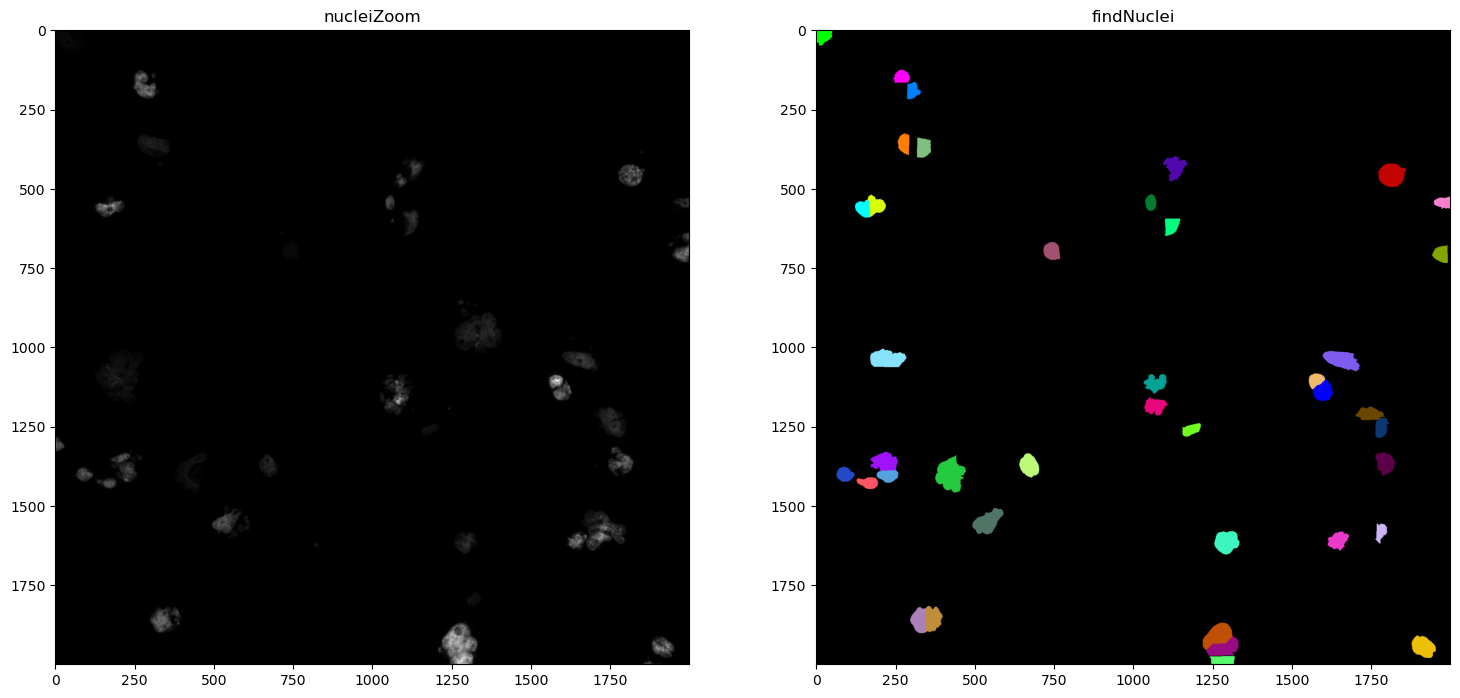

In [26]:
myColors = ListedColormap([(0, 0, 0)] + distinctipy.get_colors(int(findNuclei.max())))

fig, ax = plt.subplots(ncols = 2, figsize = (18, 18))
ax[0].imshow(nucleiZoom, cmap = "gray")
ax[1].imshow(findNuclei, cmap=myColors)
ax[0].set_title("nucleiZoom")
ax[1].set_title("findNuclei")
plt.show()

In [8]:
print("hi")

hi
